In [1]:
import numpy as np
import scipy
import time
from skimage.feature import peak_local_max
import matplotlib.pyplot as plt
%matplotlib inline

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.weight": "bold",
    "axes.linewidth": 2,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "axes.labelsize": 16,
    "axes.titlesize": 20,
    "legend.fontsize": 16,
    #"legend.edgecolor": 'white'
})

#define parameters as in the notebook
qs = np.linspace(1e-4, 0.0035, num=10)
n_max=80
k = 10 #10 by default
q=0.01
Omega_r=q #0.8
Omega_i=q #0.8
Omega_0=0.01

#defines function from eq 23 of the paper and then finds the fourier cosine transform
def Fr(theta, a):
    return np.sin(theta/2)/np.pi*np.arctan(a/(2*np.sin(theta/2)**3))
    
def Fi(theta, a):
    return np.sin(theta/2)/(2*np.pi)*np.log(1+a**2/(np.sin(theta/2)**6))

def F(n, a):
    theta = np.linspace(0.001, 2 * np.pi, num=1000, endpoint=True)
    res = np.trapezoid(Fr(theta, a)*np.cos(n*theta), x=theta)
    res2 = np.trapezoid(Fi(theta, a)*np.cos(n*theta), x=theta)
    return (res + 1j*res2)/(2*np.pi)

#fourier component matrix
def M(n_max, Omega_r, Omega_i, Omega_0, q):
    alpha = np.sqrt(Omega_0/0.06)
    beta = F(0,Omega_r*alpha)
    m = np.zeros((n_max, n_max), dtype=complex)
    np.fill_diagonal(m[0:,1:], -q/2)
    np.fill_diagonal(m[1:,0:], -q/2)
    m[0,1]=-q
    Fn = np.array([beta-F(n,Omega_r*alpha) if n < n_max-k 
                   else beta for n in range(n_max)])
    np.fill_diagonal(m, Omega_r+1j*Omega_i+Fn)
    return m

start = time.time()
end = time.time()
print(str((end-start)/60) + ' mins')
#test on the real matrix in the previous paper https://arxiv.org/abs/2304.04720
print(qs)

1.1205673217773438e-06 mins
[0.0001     0.00047778 0.00085556 0.00123333 0.00161111 0.00198889
 0.00236667 0.00274444 0.00312222 0.0035    ]


In [2]:
#plot the smallest eigenvalue for all points on the grid
start2 = time.time()
eigs = np.zeros((100,100))
for i in range(1,100):
    for j in range(1,100):
        eigs[i,j] = np.abs(scipy.sparse.linalg.eigs(M(n_max, i/100*Omega_r, -j/100*Omega_i, Omega_0, q), k=1, sigma=0, which='LM', return_eigenvectors=False, maxiter=1000))[0]

end2 = time.time()
print(end2-start2)

732.5243954658508


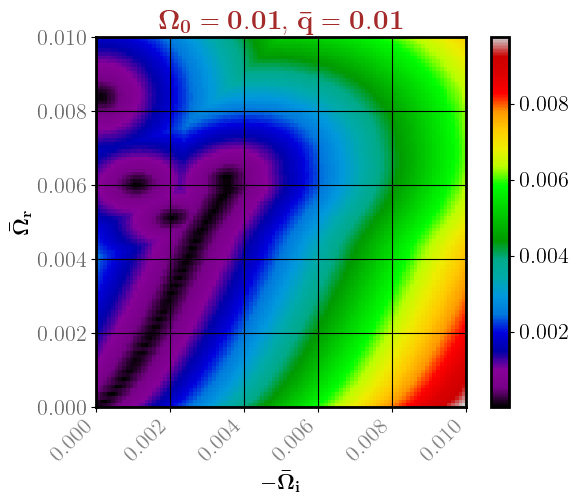

In [3]:
plt.colorbar(plt.imshow(eigs[1:,1:], extent=[0, Omega_i, 0, Omega_r], origin='lower', cmap='nipy_spectral'))
#plt.colorbar(plt.imshow(eigs[1:,1:], extent=[0, Omega_i/3, 0, Omega_r], origin='lower', cmap='nipy_spectral', aspect=0.33))
plt.ylabel("$\\bf {\\bar \\Omega_r}$")
plt.xlabel("$-\\bf {\\bar \\Omega_i}$")
plt.title("${\\bf \\Omega_0=0.01}, $"+" $\\bf {\\bar q=0.01}$"#+str(np.round(q,4))
, color='brown')
#hardcode it just for the 3 values of q we use in the paper?
plt.xticks(rotation=45, ha='right', color='gray')
plt.yticks(color='dimgray')
plt.grid(color='black')
plt.savefig("eigs_q_"+str(q)+".pdf", bbox_inches='tight')

[0.0026 0.0029 0.0021 0.002  0.0025 0.0022 0.0028 0.002  0.0016 0.001
 0.0023 0.0024 0.0015 0.0001 0.0024 0.0017 0.0019]
[0.0044 0.0049 0.0032 0.005  0.0042 0.0034 0.0047 0.003  0.0023 0.0059
 0.0036 0.004  0.0021 0.0083 0.0038 0.0025 0.0028]


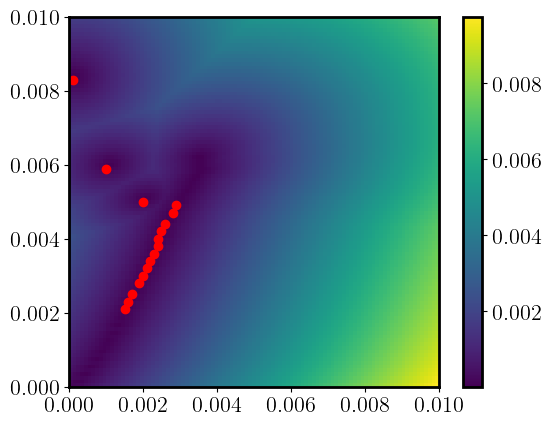

In [4]:
#find all local minima and then restrict to the ones we want
xy=peak_local_max(-eigs[1:,1:])
#plt.scatter(xy[:,1], xy[:,0], marker='o', color='r')
plt.colorbar(plt.imshow(eigs[1:,1:], extent = [0, Omega_i, 0, Omega_r], origin='lower'))
xy1 = xy[xy[:,0]>20]
xy2 = xy1[xy1[:,1]<30]
plt.scatter(xy2[:,1]*Omega_i/100, xy2[:,0]*Omega_r/100, color='r')
print(xy2[:,1]*Omega_i/100)
print(xy2[:,0]*Omega_r/100)

C:\Users\asavanur\AppData\Local\Temp\ipykernel_7556\657674934.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


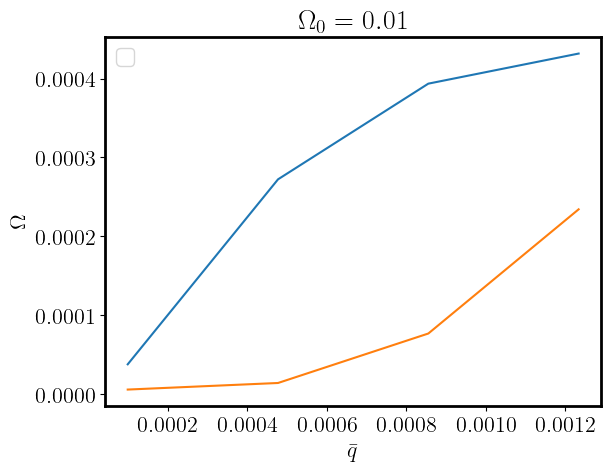

In [5]:
#locations of the islands obtained from the previous cell
x1=[1.3e-05, 2.1e-05, 1.9e-05, 8.0e-06, 1.0e-06, 6.0e-06, 1.5e-05, 4.0e-06, 1.0e-05, 1.1e-05]
x2=[9.55555556e-05, 1.19444444e-04, 4.77777778e-05, 6.68888889e-05, 3.34444444e-05, 1.43333333e-05, 1.09888889e-04, 8.12222222e-05, 1.33777778e-04, 1.48111111e-04]
x3=[2.13888889e-04, 2.05333333e-04, 3.42222222e-05, 2.39555556e-04, 1.45444444e-04, 7.70000000e-05, 1.11222222e-04, 1.71111111e-04, None, None]
x4=[6.16666667e-05, 1.72666667e-04, 2.83666667e-04, 3.33000000e-04, 1.23333333e-04, 2.34333333e-04, None, None, None, None]
x5=[3.38333333e-04, 1.77222222e-04, 8.05555556e-05, 4.02777778e-04, 2.57777778e-04, None, None, None, None, None]
x6=[0.00023867, 0.00033811, 0.00011933, 0.00043756, 0.000537, None, None, None, None, None]
x7=[0.000426, 0.00068633, 0.000284, 0.000568, 0.000142, None, None, None, None, None]
x8=[0.00019211, 0.00052144, 0.00068611, 0.00035678, None, None, None, None, None, None]
x9=[0.00021856, 0.00081178, 0.00062444, 0.00043711, None, None, None, None, None, None]
x10=[0.000945, 0.000245, 0.00049, 0.000735, None, None, None, None, None, None]
x = np.stack((x1,x2,x3,x4,x5,x6,x7,x8,x9,x10))
y1=[2.4e-05, 1.7e-05, 1.8e-05, 3.3e-05, 5.6e-05, 3.8e-05, 2.2e-05, 4.5e-05, 2.9e-05, 2.6e-05]
y2=[0.00013378, 0.00011467, 0.00018633, 0.00016244, 0.00021978, 0.00027233, 0.00012422, 0.00014811, 0.00010989, 0.00010033]
y3=[0.00013689, 0.00024811, 0.00048767, 0.000231, 0.00029944, 0.00039356, 0.00033367, 0.00026522, None, None]
y4=[0.000703, 0.00049333, 0.00039467, 0.00037, 0.00056733, 0.00043167, None, None, None, None]
y5=[0.00058, 0.00075722, 0.00091833, 0.00053167, 0.00064444, None, None, None, None, None]
y6=[0.00093478, 0.00081544, 0.00113367, 0.000716, 0.00065633, None, None, None, None, None]
y7=[0.00097033, 0.00080467, 0.00111233, 0.00087567, 0.00137267, None, None, None, None, None]
y8=[0.00159178, 0.00112522, 0.00101544, 0.00128989, None, None, None, None, None, None]
y9=[0.00181089, 0.00118644, 0.00131133, 0.00149867, None, None, None, None, None, None]
y10=[0.00133, 0.00203, 0.00168, 0.00147, None, None, None, None, None, None]
y = np.stack((y1,y2,y3,y4,y5,y6,y7,y8,y9,y10))
qss = np.stack([qs] * 10)
plt.plot(qs, y[:,5]) #real
plt.plot(qs,x[:,5])
plt.title("$\\Omega_0=0.01$")
plt.xlabel("$\\bar q$")
plt.ylabel("$\\Omega$")
plt.legend()
#plt.savefig("zerosoundsmallq.pdf")

In [6]:
#take the log, then take the gradient, then apply a gaussian blur to remove noise and make the minimums easier to see
#grad = scipy.ndimage.gaussian_filter(np.gradient(np.log(eigs[1:,1:])/np.log(10))[0],1)
#remove all values less than a threshold to remove remaining noise
#grad[abs(grad) <= 5*np.std(grad)]=0
#find where the sign of the denoised gradient changes
#asign = np.sign(grad)
#signchange = ((np.roll(asign, 1) - asign) > 0).astype(int)
#plt.colorbar(plt.imshow(eigs[1:,1:], extent=[0, Omega_i, 0, Omega_r], origin='lower'))
#plot the precise location of the minimum (manually)
#plt.scatter([0.0001], [0.0083], marker='o', color='r')
#plt.colorbar(plt.imshow(signchange, extent=[0, Omega_i,0, Omega_r], origin = 'lower', cmap='binary'))
#plt.grid()

1.4084350527209015
1.3756748451067435
1.2413854617722442


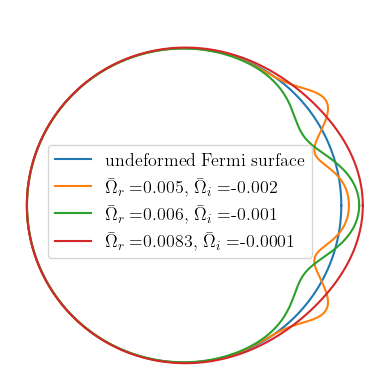

In [7]:
#find the smallest eigenvector at the locations of the islands and then plot the Fermi surface for each
eigvals1, A1 = np.linalg.eig(M(n_max, 50/100*Omega_r, -20/100*Omega_i, Omega_0, q))
A1 = A1[:,np.argmin(np.abs(eigvals1))]
norm1 = np.real(np.sqrt(2*np.sum(A1*np.conj(A1))-A1[0]*np.conj(A1[0])))
print(norm1)

eigvals2, A2 = np.linalg.eig(M(n_max, 60/100*Omega_r, -10/100*Omega_i, Omega_0, q))
A2 = A2[:,np.argmin(np.abs(eigvals2))]
norm2 = np.real(np.sqrt(2*np.sum(A2*np.conj(A2))-A2[0]*np.conj(A2[0])))
print(norm2)

eigvals3, A3 = np.linalg.eig(M(n_max, 83/100*Omega_r, -1/100*Omega_i, Omega_0, q))
A3 = A3[:,np.argmin(np.abs(eigvals3))]
norm3 = np.real(np.sqrt(2*np.sum(A3*np.conj(A3))-A3[0]*np.conj(A3[0])))
print(norm3)

theta = np.linspace(0,2*np.pi,400)
def polar_r(t, A, norm):
    return np.array([(2*np.sum([A[i]*np.cos(i*theta) for i in range(n_max)])-A[0])/norm for theta in theta])

plt.plot(20*np.cos(theta), 20*np.sin(theta), label='undeformed Fermi surface')
plt.plot((20+np.real(polar_r(theta,A1,norm1)))*np.cos(theta), (20+np.real(polar_r(theta,A1,norm1)))*np.sin(theta),
        label='$\\bar \\Omega_r=$'+str(np.round(50/100*Omega_r,4))+', '+'$\\bar \\Omega_i=$'+str(np.round(-20/100*Omega_i,4)))
plt.plot((20+np.real(polar_r(theta,A2,norm2)))*np.cos(theta), (20+np.real(polar_r(theta,A2,norm2)))*np.sin(theta),
        label='$\\bar \\Omega_r=$'+str(np.round(60/100*Omega_r,4))+', '+'$\\bar \\Omega_i=$'+str(np.round(-10/100*Omega_i,4)))
plt.plot((20+np.real(polar_r(theta,A3,norm3)))*np.cos(theta), (20+np.real(polar_r(theta,A3,norm3)))*np.sin(theta),
        label='$\\bar \\Omega_r=$'+str(np.round(83/100*Omega_r,4))+', '+'$\\bar \\Omega_i=$'+str(np.round(-1/100*Omega_i,4)))
plt.axis('square')
plt.axis('off')
#plt.xlabel("$k_x$")
#plt.ylabel("$k_y$")
#plt.title("Fermi surfaces near special $\\Omega$ values,"+" q="+str(np.round(q,4)))
plt.legend(fontsize=13, bbox_to_anchor=[0.46, 0.48])
#plt.savefig("fermisurface.pdf")

In [8]:
#find the eigenvalues that we want for all the qs we want in a vectorized way
#qs = np.linspace(1e-4, 0.0035, num=10)
#start2 = time.time()
#test22 = np.zeros((len(qs),100,100,n_max,n_max)).astype(complex)
#for i in range(100):
#    for j in range(100):
#        for k in range(len(qs)):
#            test22[k,i,j]=M(n_max, i/100*Omega_r, -j/100*Omega_i, Omega_0, qs[k])

#test2eigs = scipy.linalg.eigvals(test22)
#end2 = time.time()
#test2eigsm = np.abs(np.min(test2eigs, axis=3))
#print(test2eigsm.shape)
#print(end2-start2)

In [9]:
#plt.figure(1)
#plt.colorbar(plt.imshow(test2eigsm[8,1:,1:], extent=[0, Omega_i, 0, Omega_r], origin = 'lower'))
#plt.ylabel("$\\Omega_r$")
#plt.xlabel("$-\\Omega_i$")
#plt.title("$\\Omega_0=0.01, q= $"+str(qs[9]))
#take the log, then take the gradient, then apply a gaussian blur to remove noise and make the minimums easier to see
#grad = scipy.ndimage.gaussian_filter(np.gradient(np.log(test2eigsm[:,1:,1:])/np.log(10))[0],1)
#plt.figure(2)
#plt.colorbar(plt.imshow(grad[3,:,:], extent=[0, Omega_r, 0, Omega_i], origin = 'lower'))
#remove all values less than a threshold to remove remaining noise
#for i in range(grad.shape[0]):
#    grad[i][abs(grad[i]) <= 5*np.std(grad[i])]=0
#find where the sign of the denoised gradient changes
#asign = np.sign(grad)
#signchange = ((np.roll(asign, 1) - asign) > 0).astype(int)
#print(signchange.shape)

#plt.figure(3)
#plt.colorbar(plt.imshow(signchange[3], extent=[0, Omega_r, 0, Omega_i], origin = 'lower'))

#consolidate all the positions where the sign change is not 0 into an array instead of a variable length list
#def cons(a, dim):
#     wer = [np.nonzero(a[i])[dim] for i in range(a.shape[0])]
#     lene = np.max([len(wer[i]) for i in range(len(wer))])
#     wer2 = np.array([np.concatenate((np.array(wer[i]), np.zeros(lene-len(wer[i])))) for i in range(len(wer))])
      #wer3 = np.average(wer2, axis=1)
#     return wer2

#cons_i = cons(signchange, 0)
#cons_r = cons(signchange, 1)

#find the minimum of the matrix slices programmatically
#min_r = np.zeros(len(qs))
#min_i = np.zeros(len(qs))

#for i in range(len(qs)):
#    ind = np.unravel_index(np.argmin(test2eigsm[i,1:,1:], axis=None), test2eigsm[i,1:,1:].shape)
#    min_r[i] = ind[0]
#    min_i[i] = ind[1]

#plt.figure(4)
#plt.plot(qs, min_r*Omega_r/100, label='real part')
#plt.plot(qs, min_i*Omega_i/100, label='imag part')
#plt.xlabel("q")
#plt.ylabel("$\\Omega$")
#plt.title("$\\Omega_0=0.01$")
#plt.legend()

[0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9]
[0.085 0.175 0.26  0.35  0.43  0.53  0.62  0.71  0.8  ]
[0.005  0.0125 0.019  0.025  0.03   0.04   0.05   0.05   0.06  ]


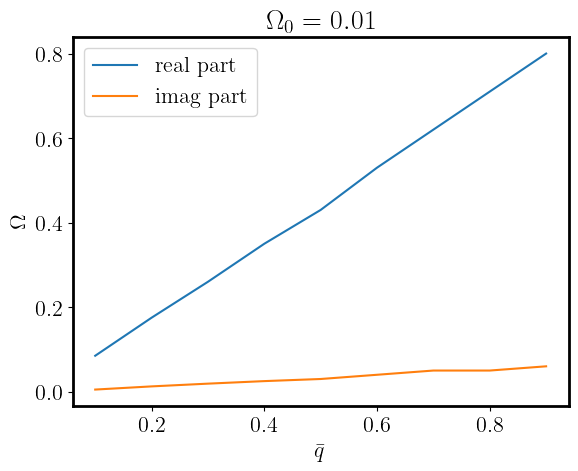

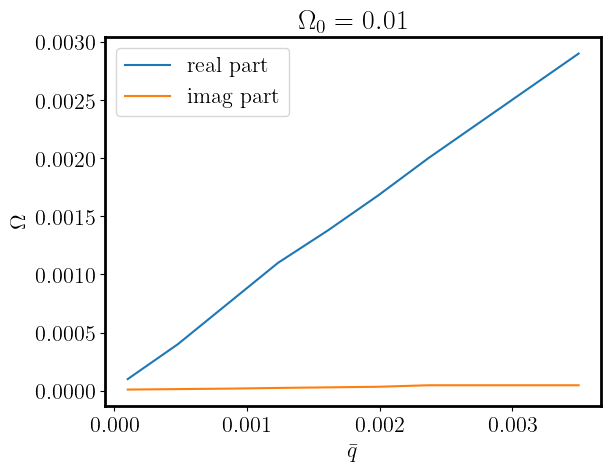

In [10]:
#manually found the minimum and plotted it here (at large q)
zone_b=np.array([[0.022, 0.082], [0.03, 0.175], [0.04, 0.26], [0.05, 0.35], [0.06, 0.44], [0.067, 0.55], [0.08, 0.64], [0.085, 0.73], [0.1, 0.83]])
island=np.array([[0.005, 0.085],[0.0125, 0.175],[0.019, 0.26],[0.025, 0.35],[0.03, 0.43],[0.04, 0.53],[0.05, 0.62],[0.05, 0.71],[0.06, 0.8]])
q1 = np.arange(0.1,1,0.1)
#plt.figure(1)
#plt.plot(q1, zone_b.T[1], label='real part')
#plt.plot(q1, zone_b.T[0], label='imag part')
#plt.legend()
#plt.title("zone boundary")
#plt.xlabel("q")
#plt.ylabel("$\\Omega$")
#plt.savefig("zoneboundary.pdf")
plt.figure(2)
plt.plot(q1, island.T[1], label='real part')
plt.plot(q1, island.T[0], label='imag part')
plt.legend()
plt.title("zero sound dispersion")
plt.xlabel("$\\bar q$")
plt.ylabel("$\\Omega$")
plt.title("$\\Omega_0=0.01$")
#plt.savefig("island.pdf")
plt.figure(3)
plt.plot(qs, [0.0001, 0.0004, 0.00075, 0.0011, 0.00138, 0.00168, 0.002, 0.0023, 0.0026, 0.0029], label='real part')
plt.plot(qs, [0.00001, 0.000014, 0.000018, 0.000024, 0.000029, 0.000034, 0.000047, 0.000047, 0.000047, 0.000047], label='imag part')
plt.ylabel("$\\Omega$")
plt.xlabel("$\\bar q$")
plt.title("$\\Omega_0=0.01$")
plt.legend()
#plt.savefig("zerosoundsmallq.pdf", bbox_inches="tight")
print(q1)
print(island.T[1])
print(island.T[0])